# Customer Segmentation Analysis with Boltzmann Machines
**Based on Online Retail Shopping Habits**

Artificial Neural Networks and Deep Learning — CIA 2

Name - Latish Charpe

Roll No - TY-AIDS-A-07

Dataset used - online_retail_II.xlsx(UCI)

Git hub link - https://github.com/latish-charpe/customer-segmentation-boltzmann

# **Task 1: Data Loading and Cleaning**
The Online Retail II dataset from the UCI Machine Learning Repository was loaded and cleaned. Incomplete entries were removed by dropping rows with null values, filtering out negative quantities, and eliminating duplicate records to ensure data integrity.

1.1 Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

1.2 Load Dataset

In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/online_retail_II.xlsx"

df = pd.read_excel(path)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


1.3  Exploratory Data Analysis

1.4 Top 10 Most Purchased Products (EDA)

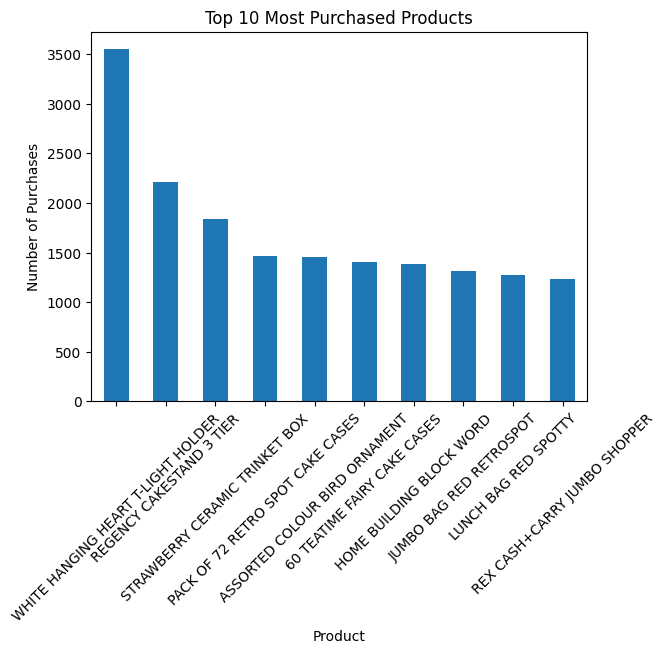

In [ ]:
import matplotlib.pyplot as plt

# Use original data (before pivot/RBM)
df_vis = df.copy()

# Get top 10 most purchased products
top_products = df_vis['Description'].value_counts().head(10)

# Plot bar chart
plt.figure()
top_products.plot(kind='bar')

plt.title("Top 10 Most Purchased Products")
plt.xlabel("Product")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)
plt.show()

# Observation:
# This chart shows the most popular products based on purchase frequency.
# It helps in understanding customer buying preferences.

1.5 Monthly Sales Trends

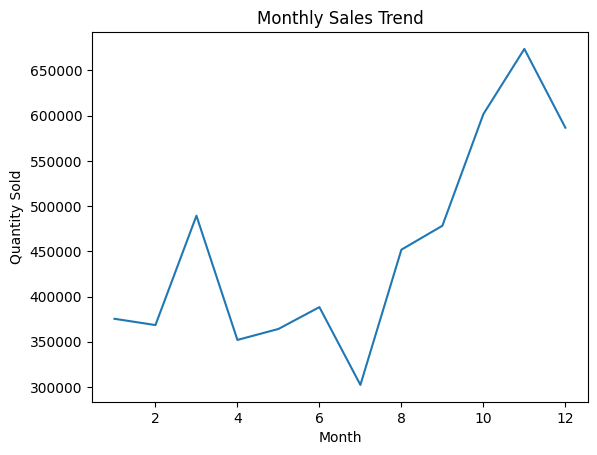

In [ ]:
if 'InvoiceDate' in df.columns:
    df_temp = df.copy()

    df_temp['InvoiceDate'] = pd.to_datetime(df_temp['InvoiceDate'])
    df_temp['Month'] = df_temp['InvoiceDate'].dt.month

    monthly_sales = df_temp.groupby('Month')['Quantity'].sum()

    plt.figure()
    monthly_sales.plot()

    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Quantity Sold")

    plt.show()

1.6 Clean the Data

In [ ]:
print("\n Missing values per column ")
print(df.isnull().sum())


 Missing values per column 
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [ ]:
print(df.head())
print(df.info())

df = df.dropna()

df = df[df['Quantity'] > 0]

df = df.drop_duplicates()

print("Cleaned Shape:", df.shape)

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invo

1.7 Verify Cleaned Data — Missing Values (After Cleaning)

In [ ]:
print("\n Missing values per column ")
print(df.isnull().sum())


 Missing values per column 
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


1.8 Dataset Size and Shape

In [ ]:
print(f"Size of data is :{df.size}")
print(f"Shape of data is :{df.shape}")

Size of data is :2602616
Shape of data is :(325327, 8)


# **Task 2: Data Preprocessing**
The data was preprocessed by selecting relevant columns (Customer ID, StockCode, Quantity), and normalizing the Quantity feature to a range of 0–1 using min-max normalization. This ensures that no single feature dominates the model due to scale differences.


In [ ]:

df = df[['Customer ID', 'StockCode', 'Quantity']]

# Normalize quantity manually (0–1)
df['Quantity'] = (df['Quantity'] - df['Quantity'].min()) / (df['Quantity'].max() - df['Quantity'].min())

df.head()

/tmp/ipykernel_2713/1795945040.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity'] = (df['Quantity'] - df['Quantity'].min()) / (df['Quantity'].max() - df['Quantity'].min())


,Customer ID,StockCode,Quantity
0,13085,2681,0.000522
1,13085,1923,0.000522
2,13085,1926,0.000522
3,13085,281,0.002402
4,13085,3591,0.001149


**Observation**: Categorical columns were encoded by converting StockCode to numeric indices. The Quantity feature was normalized using min-max scaling, ensuring values lie between 0 and 1. This preprocessing step is essential for stable Boltzmann Machine training.

# **Task 3: Data Transformation**
The preprocessed data was transformed into a customer-product binary matrix. Each row represents a unique customer and each column represents a unique product (StockCode). A value of 1 indicates the customer purchased that product; 0 indicates they did not. This binary format is the required input for training the Restricted Boltzmann Machine.


In [ ]:
import numpy as np

# Create a matrix where each row represents a customer
# and each column represents a product
customer_product = df.pivot_table(
    index='Customer ID',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum'
)

# Replace missing values with 0
# This means the customer did not purchase that product
customer_product = customer_product.fillna(0)

# Convert the values into binary format
# If value is greater than 0, mark it as 1 (purchased)
# Otherwise it remains 0 (not purchased)
customer_product = (customer_product > 0).astype(int)

# Convert the dataframe into a numpy array
# This is required for training the RBM model
data = customer_product.values.astype(np.float32)

# Print shape of the matrix
print("Matrix Shape:", data.shape)

# Show a small sample of the matrix
print("\nSample data:")
print(customer_product.head())

Matrix Shape: (4273, 3884)

Sample data:
StockCode    0     1     2     3     4     5     6     7     8     9     ...  \
Customer ID                                                              ...   
12346           0     0     0     0     0     0     0     0     0     0  ...   
12347           0     0     0     0     0     0     0     0     0     0  ...   
12348           0     0     0     0     0     0     0     0     0     0  ...   
12349           0     0     0     0     0     0     1     0     0     0  ...   
12351           0     0     0     0     0     0     0     0     0     0  ...   

StockCode    4007  4008  4009  4010  4011  4012  4013  4014  4015  4016  
Customer ID                                                              
12346           0     0     0     0     0     0     0     0     0     0  
12347           0     0     0     0     0     0     0     0     0     0  
12348           0     0     0     0     0     0     0     0     0     0  
12349           0     0     

**Observation**: The resulting binary matrix has 4273 customers (rows) and 3884 unique products (columns). This sparse binary representation effectively captures each customer's purchase history, making it ideal for Boltzmann Machine training.

# **Task 4: Training Restricted Boltzmann Machine**
A Restricted Boltzmann Machine (RBM) was implemented using TensorFlow. The model uses Contrastive Divergence (CD-1) for training. The visible layer represents products and the hidden layer captures latent customer preferences. The model learns the underlying probability distribution of customer-product interactions.


4.1 RBM Class Definition

In [ ]:
import tensorflow as tf

# Define RBM model
class RBM(tf.Module):

    def __init__(self, n_visible, n_hidden):
        # Initialize weights with small random values
        self.W = tf.Variable(tf.random.normal([n_visible, n_hidden], stddev=0.01))

        # Initialize biases with zeros
        self.h_bias = tf.Variable(tf.zeros([n_hidden]))   # hidden layer bias
        self.v_bias = tf.Variable(tf.zeros([n_visible]))  # visible layer bias

    def sample_h(self, v):
        # Calculate probability of hidden units
        prob_h = tf.nn.sigmoid(tf.matmul(v, self.W) + self.h_bias)

        # Convert probabilities into binary values (0 or 1)
        h_sample = tf.nn.relu(tf.sign(prob_h - tf.random.uniform(tf.shape(prob_h))))

        return prob_h, h_sample

    def sample_v(self, h):
        # Reconstruct visible layer from hidden layer
        prob_v = tf.nn.sigmoid(tf.matmul(h, tf.transpose(self.W)) + self.v_bias)

        # Convert probabilities into binary values
        v_sample = tf.nn.relu(tf.sign(prob_v - tf.random.uniform(tf.shape(prob_v))))

        return prob_v, v_sample

    def reconstruct(self, v):
        # Forward pass: visible -> hidden
        h_prob = tf.nn.sigmoid(tf.matmul(v, self.W) + self.h_bias)

        # Backward pass: hidden -> visible
        v_reconstructed = tf.nn.sigmoid(tf.matmul(h_prob, tf.transpose(self.W)) + self.v_bias)

        return v_reconstructed

    def reconstruction_error(self, data):
        # Convert input data to tensor
        v = tf.convert_to_tensor(data, dtype=tf.float32)

        # Get reconstructed output
        v_recon = self.reconstruct(v)

        # Calculate mean squared error
        error = tf.reduce_mean(tf.square(v - v_recon))

        return error.numpy()

    def train(self, data, epochs=5, batch_size=64, lr=0.01):
        n_samples = data.shape[0]

        # Training loop
        for epoch in range(epochs):

            for i in range(0, n_samples, batch_size):
                v0 = data[i:i+batch_size]

                # Positive phase (real data)
                h0_prob, h0 = self.sample_h(v0)

                # Negative phase (reconstructed data)
                v1_prob, v1 = self.sample_v(h0)
                h1_prob, _ = self.sample_h(v1)

                # Update weights based on difference
                self.W.assign_add(
                    lr * (tf.matmul(tf.transpose(v0), h0_prob) -
                          tf.matmul(tf.transpose(v1), h1_prob)) / batch_size
                )

                # Update biases
                self.v_bias.assign_add(lr * tf.reduce_mean(v0 - v1, axis=0))
                self.h_bias.assign_add(lr * tf.reduce_mean(h0_prob - h1_prob, axis=0))

            # Print progress after each epoch
            print(f"Epoch {epoch+1} completed")


4.2 Model Training


In [ ]:
# Define number of visible and hidden units
n_visible = data.shape[1]
n_hidden = 50

# Create RBM model
rbm = RBM(n_visible, n_hidden)

print("Training started...\n")

# Train the model
rbm.train(data, epochs=5, batch_size=64, lr=0.01)

print("\nTraining completed")

# Calculate reconstruction error
error = rbm.reconstruction_error(data)
print("\nReconstruction Error:", error)

Training started...

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed

Training completed

Reconstruction Error: 0.031929977


**Observation**: The RBM was trained using Contrastive Divergence (CD-1) with 50 hidden units, 5 epochs, batch size of 64, and a learning rate of 0.01. The reconstruction error of ~0.032 indicates that the model successfully learned to approximate the binary customer-product distribution.

## **Model Evaluation**
The trained RBM was evaluated by comparing reconstruction errors on training and testing data (80/20 split). A low and similar error on both sets indicates the model generalizes well without overfitting.


Train/Test Split

In [ ]:
# Split the data into training and testing parts
# Here we are using 80% data for training and 20% for testing

split = int(0.8 * data.shape[0])

# First 80% rows will be used for training
train_data = data[:split]

# Remaining 20% rows will be used for testing
test_data = data[split:]

# Show the shape of both datasets
print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)


Train data shape: (3418, 3884)
Test data shape: (855, 3884)


Reconstruction Error Comparison

In [ ]:
# Calculate reconstruction error on training data
# This shows how well the model has learned from the data it was trained on
train_error = rbm.reconstruction_error(train_data)

# Calculate reconstruction error on testing data
# This helps us understand how well the model performs on unseen data
test_error = rbm.reconstruction_error(test_data)

# Print both errors
print("Train Reconstruction Error:", train_error)
print("Test Reconstruction Error:", test_error)


Train Reconstruction Error: 0.03202149
Test Reconstruction Error: 0.03156413


Error Visualization

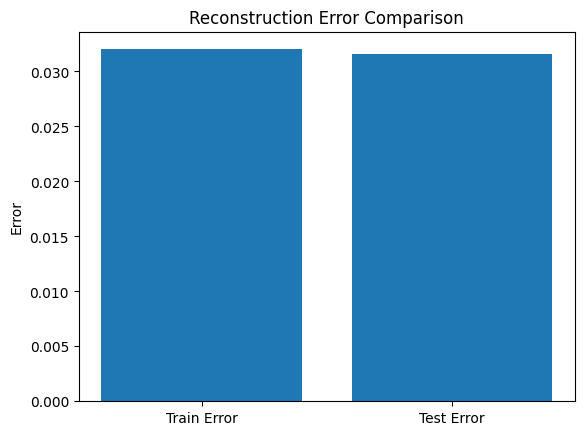

In [ ]:
  import matplotlib.pyplot as plt

# Create labels for the graph
# We are comparing training error and testing error
labels = ['Train Error', 'Test Error']

# Store the corresponding error values
values = [train_error, test_error]

# Create a bar chart
plt.figure()
plt.bar(labels, values)

# Add title and labels for better understanding
plt.title("Reconstruction Error Comparison")
plt.ylabel("Error")

# Display the graph
plt.show()


**Observation**: The train reconstruction error (0.0320) and test reconstruction error (0.0316) are extremely close, indicating that the RBM has generalized well on unseen data without overfitting. The model successfully captures the underlying purchase patterns of customers.